# Analisis de Estacionalidad

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [9]:
v_cordoba = pd.read_excel("Cordoba.xlsx")
v_cordoba.head()

,,V_Resident,V_Extranj
0,2005M01,27816,9332
1,2005M02,34920,11387
2,2005M03,45221,21663
3,2005M04,41027,29094
4,2005M05,50750,32076


In [10]:
#Se observa que la columna de las fechas no tiene nombre, por lo que:
v_cordoba.columns=['Date','V_Resident','V_Extranj']

In [11]:
v_cordoba['Date'] = pd.to_datetime(v_cordoba['Date'], format='%YM%m')
v_cordoba.index = v_cordoba['Date']
del v_cordoba['Date']
print(v_cordoba.head())

            V_Resident  V_Extranj
Date                             
2005-01-01       27816       9332
2005-02-01       34920      11387
2005-03-01       45221      21663
2005-04-01       41027      29094
2005-05-01       50750      32076


Text(0.5, 1.0, 'Viajeros alojados en hoteles en Córdoba')

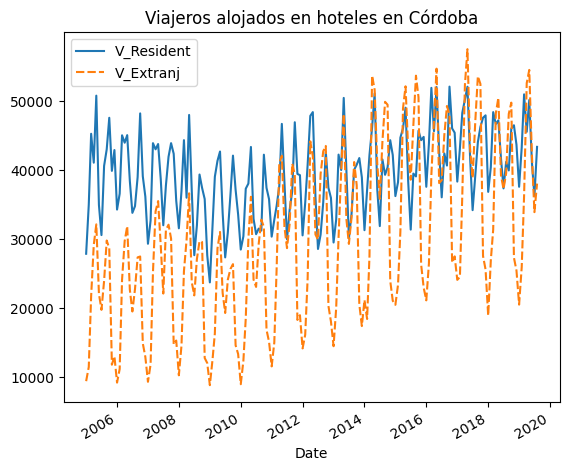

In [12]:
sns.lineplot(v_cordoba)
plt.xticks(rotation=30, ha='right')
# Ajustes de diseño
plt.title('Viajeros alojados en hoteles en Córdoba')

<Axes: xlabel='Date', ylabel='V_Extranj'>

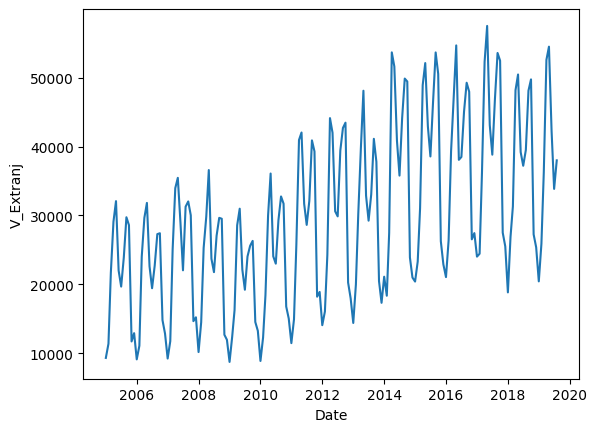

In [13]:
#Nos centramos en la variable “V_Extranj”.
sns.lineplot(v_cordoba['V_Extranj'])

In [14]:
#Descompondremos la serie temporal para conocer su estacionalidad, tendencia y residuos:
from statsmodels.tsa.seasonal import seasonal_decompose
# Realizar la descomposición estacional
result = seasonal_decompose(v_cordoba['V_Extranj'], model='multiplicative')

# Analisis de Estacionalidad

# Analisis de Estacionalidad

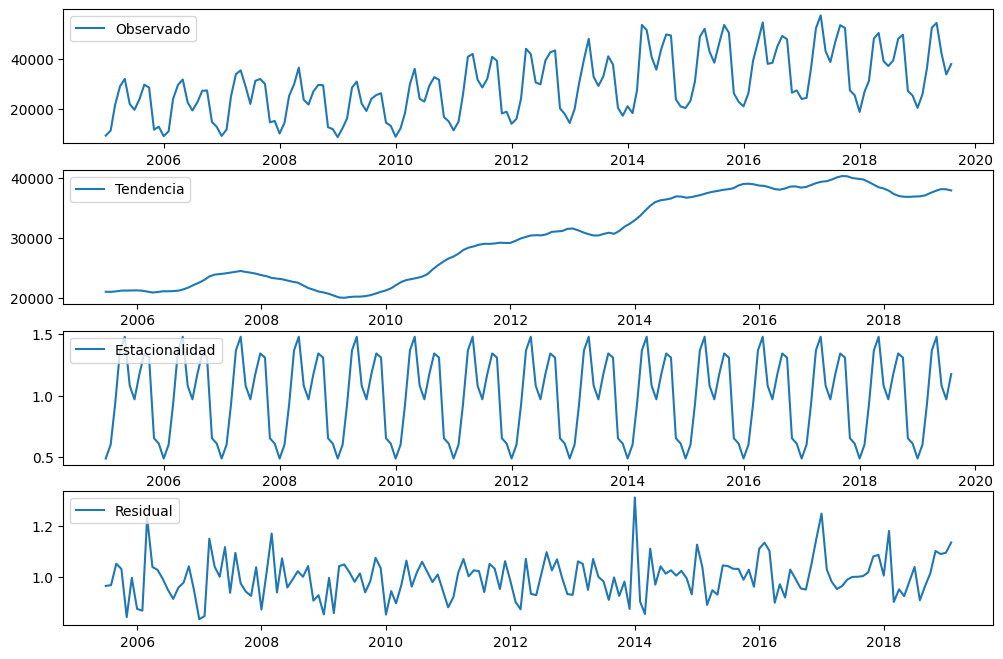

In [15]:
# Visualizar las componentes
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(result.observed, label='Observado')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(result.seasonal,
label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(result.resid,
label='Residual')
plt.legend(loc='upper left')
plt.show()

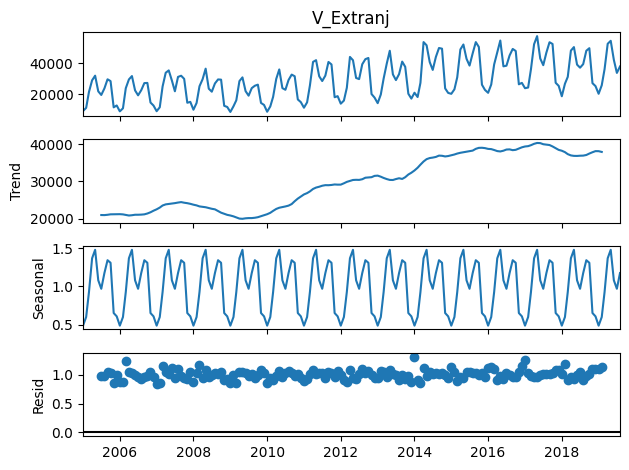

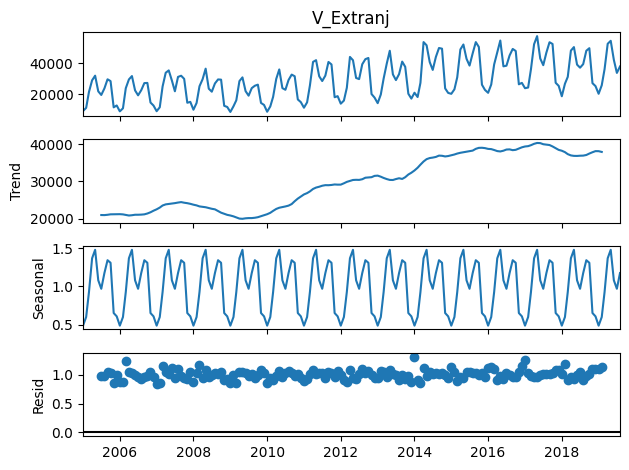

In [16]:
result.plot()

In [17]:
# Para poder observar la tasa de viajeres por mes con respecto a la media global:
print(result.seasonal)

Date
2005-01-01    0.489635
2005-02-01    0.601963
2005-03-01    0.927655
2005-04-01    1.366617
2005-05-01    1.476760
                ...   
2019-04-01    1.366617
2019-05-01    1.476760
2019-06-01    1.080087
2019-07-01    0.969568
2019-08-01    1.174033
Name: seasonal, Length: 176, dtype: float64


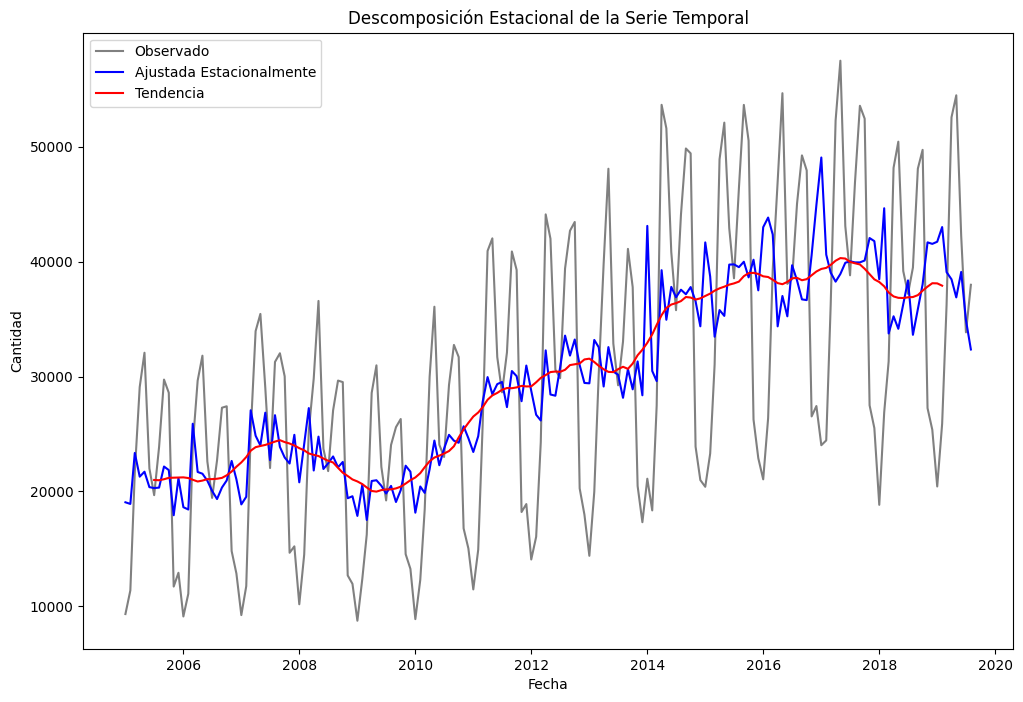

In [18]:
# Crear un gráfico que muestre las componentes
plt.figure(figsize=(12, 8))
plt.plot(result.observed, label='Observado', color='grey')
plt.plot(result.observed/result.seasonal, label='Ajustada Estacionalmente', color='blue')
plt.plot(result.trend, label='Tendencia', color='red')
# Añadir leyendas y título
plt.legend()
plt.title('Descomposición Estacional de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
# Mostrar el gráfico
plt.show()

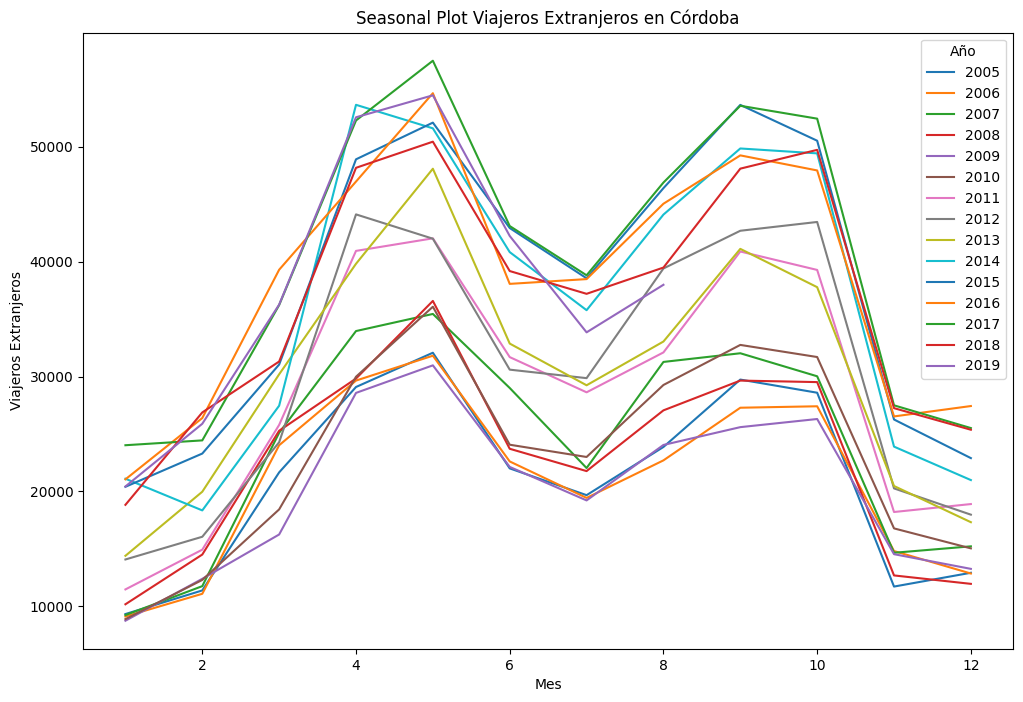

In [19]:
#Para estudiar el comportamiento estacional puede resultar útil la representación gráfica de los valores de la serie, dibujando cada año en un color diferente.
v_cordoba['Año'] = pd.to_datetime(v_cordoba.index, format='%YM%m').year
plt.figure(figsize=(12, 8))
for Año, datos_año in v_cordoba.groupby('Año'):
 plt.plot(datos_año.index.month, datos_año['V_Extranj'], label=str(Año))
# Añadir leyendas y título
plt.legend(title='Año')
plt.title('Seasonal Plot Viajeros Extranjeros en Córdoba')
plt.xlabel('Mes')
plt.ylabel('Viajeros Extranjeros')
# Mostrar el gráfico
plt.show()

# Modelo de Alisado Holt-Winters

In [20]:
# Aplicar suavizado Holt-Winters. .fit(smoothing.seasonal = gamma).
modelo_holt_winters = sm.tsa.ExponentialSmoothing(v_cordoba['V_Extranj'], trend='add', seasonal='multiplicative', seasonal_periods=12).fit()
# Obtener predicciones para 1 año
predicciones_hw = modelo_holt_winters.forecast(steps=12)
# Mostrar la descripción del modelo
modelo_holt_winters.summary()

c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Dep. Variable:,V_Extranj,No. Observations:,176
Model:,ExponentialSmoothing,SSE,1220355015.451
Optimized:,True,AIC,2804.339
Trend:,Additive,BIC,2855.066
Seasonal:,Multiplicative,AICC,2808.695
Seasonal Periods:,12,Date:,"Fri, 08 May 2026"
Box-Cox:,False,Time:,19:14:56
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2750533,alpha,True
smoothing_trend,0.000000,beta,True


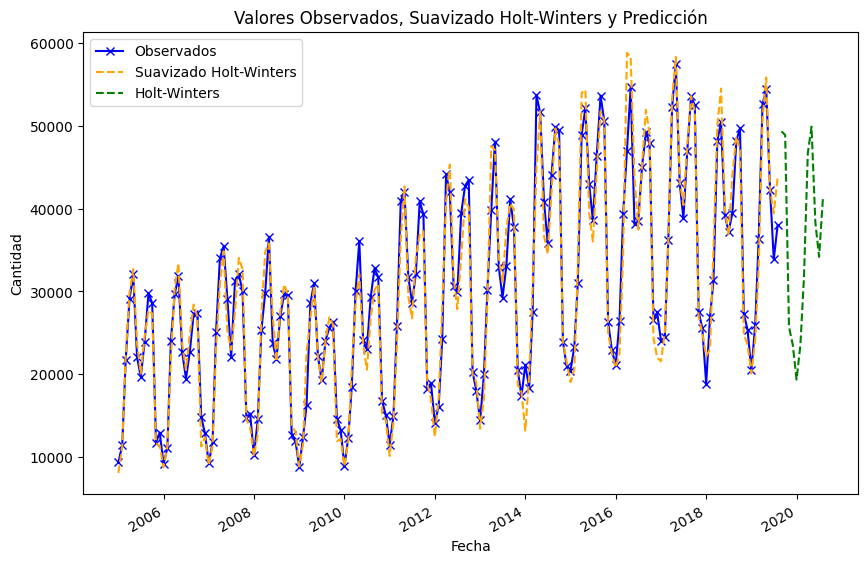

In [21]:
# Crear un gráfico con matplotlib
plt.figure(figsize=(10, 6))
plt.plot(v_cordoba.index, v_cordoba['V_Extranj'], label='Observados', marker='x', linestyle='-', color='blue')
plt.plot(v_cordoba.index, modelo_holt_winters.fittedvalues, label='Suavizado Holt-Winters', linestyle='--',
color='orange')
plt.plot(predicciones_hw.index, predicciones_hw, label='Holt-Winters', linestyle='--',color='green')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Valores Observados, Suavizado Holt-Winters y Predicción')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()